In [1]:
# Traditional Imports
import math
from fractions import Fraction
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset_sizes = [5,10,15,20,30,40,50,60,75,90,100]

## Closed-form random baselines

Both metrics are evaluated for a uniformly random ranking (untied scores). The floor used in the manuscript is mean + SD of this null distribution.

**Spearman correlation (signed):** mean = 0, SD = $1/\sqrt{n-1}$.

**Average precision** follows Theorem 1 (sampling without replacement, SWOR) of Manzhos, Ianevych & Melnyk (2026), *Modern Stochastics: Theory and Applications* 13(3), 357–374, doi:10.15559/26-VMSTA298. Among $N$ items, exactly $m$ are relevant (positive). Non-interpolated AP over the full ranking, as in `sklearn.metrics.average_precision_score`, is their $AP@k$ with cutoff $k = N$, so that $\min(k, m) = m$.

$$\operatorname{E}_{SWOR}(AP@k)=\frac{m}{N\cdot \min (k,m)}\left(\frac{m-1}{N-1}k+\frac{N-m}{N-1}{H_{k}}\right)$$

$$\operatorname{Var}_{SWOR}(AP@k)=\frac{1}{\min (k,m)^{2}}\frac{m}{N}\Big[k\big(C+2(E-F)+(k-1)G\big)+H_{k}\big(B-2(E-kF)\big)+H_{k}^{2}\cdot D+H_{k}^{(2)}(A-D)\Big]$$

where

$$A=1-\frac{m}{N}-\frac{m-1}{N-1}\left(3-2\frac{m-2}{N-2}-\frac{m}{N}\left(2-\frac{m-1}{N-1}\right)\right)$$
$$B=\frac{m-1}{N-1}\left(3\left(1-\frac{m-2}{N-2}\right)-2\frac{m}{N}\left(1-\frac{m-1}{N-1}\right)\right)$$
$$C=\frac{m-1}{N-1}\left(\frac{m-2}{N-2}-\frac{m(m-1)}{N(N-1)}\right)$$
$$D=\frac{m-1}{N-1}\left(2-5\frac{m-2}{N-2}+3\frac{(m-2)(m-3)}{(N-2)(N-3)}\right)-\frac{m}{N}\left(1-\frac{m-1}{N-1}\right)^{2}$$
$$E=\frac{m-1}{N-1}\left(3\frac{m-2}{N-2}\left(1-\frac{m-3}{N-3}\right)-\frac{m}{N}\left(1-\frac{m-1}{N-1}\right)\right)$$
$$F=\frac{m-1}{N-1}\left(\frac{m-2}{N-2}\left(1-\frac{m-3}{N-3}\right)-\frac{m}{N}\left(1-\frac{m-1}{N-1}\right)\right)$$
$$G=\frac{m-1}{N-1}\left(\frac{(m-2)(m-3)}{(N-2)(N-3)}-\frac{m}{N}\frac{m-1}{N-1}\right)$$

$$H_{k}=\sum_{i=1}^{k}\frac{1}{i},\qquad H_{k}^{(2)}=\sum_{i=1}^{k}\frac{1}{i^{2}}$$

In [3]:
def spearman_mean_sd(n):
    """Signed Spearman correlation under a random ranking."""
    return 0.0, 1.0 / np.sqrt(n - 1)


def _ratio(a, b):
    """Exact ratio a/b; returns 0 when the denominator vanishes (the matching
    numerator term is then 0 too, e.g. (m-3)/(N-3) when m = 3)."""
    return Fraction(a, b) if b != 0 else Fraction(0)


def ap_mean_sd(N, m, k=None):
    """Mean and SD of AP@k under random ranking (SWOR), Theorem 1 of
    Manzhos, Ianevych & Melnyk (2026). N items, m relevant, cutoff k (default k = N)."""
    k = N if k is None else k
    M = min(k, m)
    p0 = _ratio(m, N)              # m/N
    p1 = _ratio(m - 1, N - 1)      # (m-1)/(N-1)
    p2 = _ratio(m - 2, N - 2)      # (m-2)/(N-2)
    p3 = _ratio(m - 3, N - 3)      # (m-3)/(N-3)

    A = 1 - p0 - p1 * (3 - 2 * p2 - p0 * (2 - p1))
    B = p1 * (3 * (1 - p2) - 2 * p0 * (1 - p1))
    C = p1 * (p2 - p0 * p1)
    D = p1 * (2 - 5 * p2 + 3 * p2 * p3) - p0 * (1 - p1) ** 2
    E = p1 * (3 * p2 * (1 - p3) - p0 * (1 - p1))
    F = p1 * (p2 * (1 - p3) - p0 * (1 - p1))
    G = p1 * (p2 * p3 - p0 * p1)
    H_k = sum(Fraction(1, i) for i in range(1, k + 1))
    H2_k = sum(Fraction(1, i * i) for i in range(1, k + 1))

    E_SWOR = Fraction(m, N * M) * (p1 * k + _ratio(N - m, N - 1) * H_k)
    Var_SWOR = Fraction(1, M**2) * p0 * (k * (C + 2 * (E - F) + (k - 1) * G)
                                          + H_k * (B - 2 * (E - k * F))
                                          + H_k**2 * D + H2_k * (A - D))
    return float(E_SWOR), math.sqrt(max(float(Var_SWOR), 0.0))

In [4]:
# Sanity check against exact enumeration of all placements of the m relevant items
import itertools
from sklearn.metrics import average_precision_score

for N, m in [(10, 3), (15, 5), (5, 1), (15, 15)]:
    scores = np.arange(N)[::-1]
    aps = [average_precision_score(np.isin(np.arange(N), pos).astype(int), scores)
           for pos in itertools.combinations(range(N), m)]
    print(N, m, ap_mean_sd(N, m), (np.mean(aps), np.std(aps)))

10 3 (0.45003086419753086, 0.17427255264509975) (np.float64(0.45003086419753086), np.float64(0.17427255264509975))


15 5 (0.4437251901537616, 0.1373528421698822) (np.float64(0.44372519015376155), np.float64(0.1373528421698822))
5 1 (0.45666666666666667, 0.29013406862651925) (np.float64(0.45666666666666667), np.float64(0.29013406862651925))
15 15 (1.0, 0.0) (np.float64(1.0), np.float64(0.0))


## Spearman correlation

In [5]:
results_df = pd.DataFrame(columns=['SpearmanR Mean', 'SpearmanR Std'], index=dataset_sizes, dtype=float)
for size in dataset_sizes:
    results_df.loc[size] = spearman_mean_sd(size)
results_df['SpearmanR Floor'] = results_df['SpearmanR Mean'] + results_df['SpearmanR Std']

# Dense grid for the continuous line (every integer dataset size)
n_grid = np.arange(3, 101)
floor_grid = np.array([sum(spearman_mean_sd(n)) for n in n_grid])

In [6]:
results_df

,SpearmanR Mean,SpearmanR Std,SpearmanR Floor
5,0.0,0.500000,0.500000
10,0.0,0.333333,0.333333
15,0.0,0.267261,0.267261
20,0.0,0.229416,0.229416
30,0.0,0.185695,0.185695
40,0.0,0.160128,0.160128
50,0.0,0.142857,0.142857
60,0.0,0.130189,0.130189
75,0.0,0.116248,0.116248
90,0.0,0.106000,0.106000


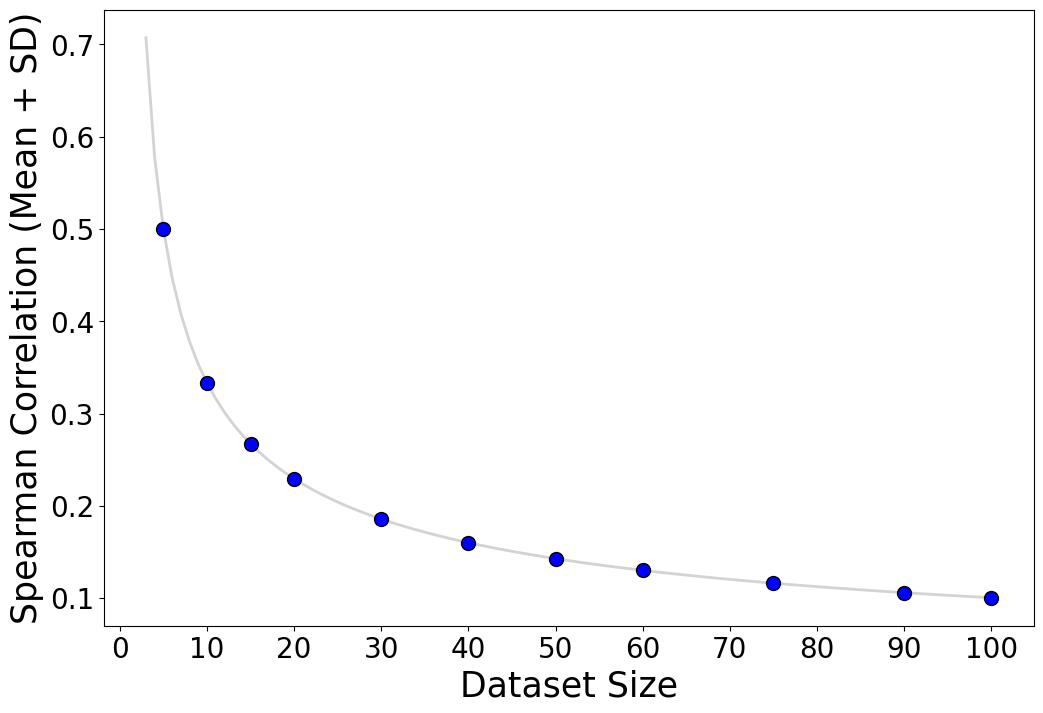

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(n_grid, floor_grid, color='lightgray', linewidth=2, zorder=1)
ax.plot(results_df.index, results_df['SpearmanR Floor'], 'o', markersize=10,
        markerfacecolor='blue', markeredgecolor='black', zorder=2)
ax.set_xlabel("Dataset Size",size=25)
ax.set_ylabel("Spearman Correlation (Mean + SD)",size=25)
ax.set_xticks(np.arange(0, 110, 10))
ax.tick_params(axis='both', which='major', labelsize=20)
plt.show()

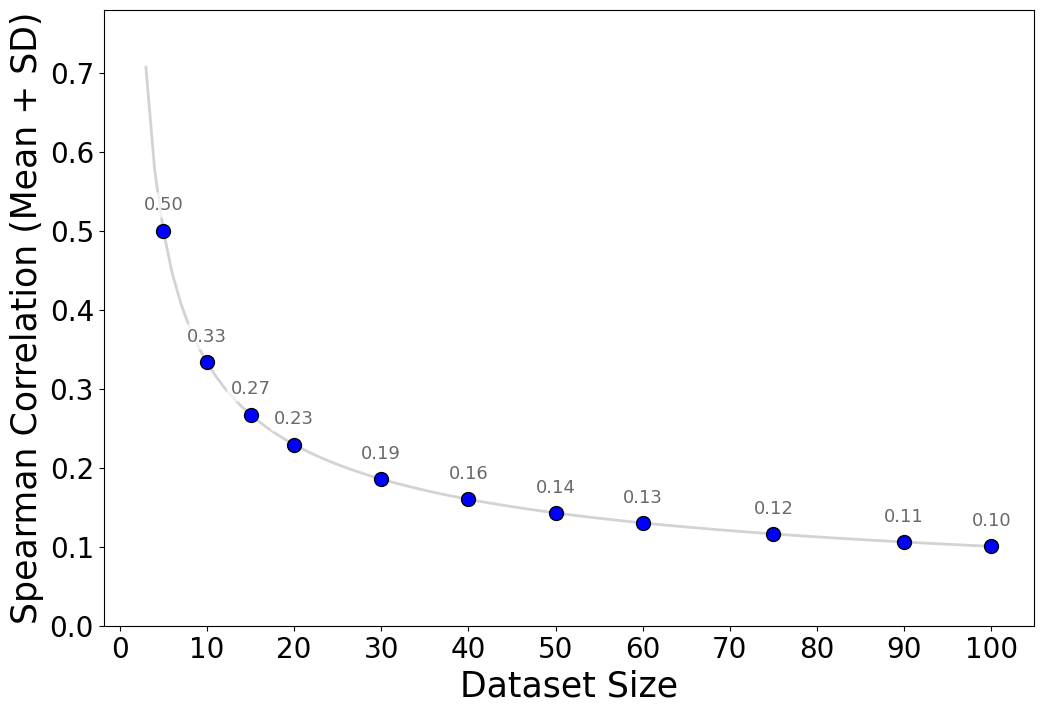

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(n_grid, floor_grid, color='lightgray', linewidth=2, zorder=1)
ax.plot(results_df.index, results_df['SpearmanR Floor'], 'o', markersize=10,
        markerfacecolor='blue', markeredgecolor='black', zorder=2)

# Annotate each point with its value, offset above the marker
for x, floor in zip(results_df.index, results_df['SpearmanR Floor']):
    ax.annotate(f"{floor:.2f}",
                xy=(x, floor), xytext=(0, 12), textcoords="offset points",
                ha="center", va="bottom", fontsize=13, color="dimgray",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

ax.set_xlabel("Dataset Size",size=25)
ax.set_ylabel("Spearman Correlation (Mean + SD)",size=25)
ax.set_xticks(np.arange(0, 110, 10))
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_ylim(0, 0.78)
plt.show()

## Average precision

In [9]:
# --- SETTINGS ---
imbalances = np.array([0.1,0.2,0.3,0.4,0.5,0.6, 0.7,0.8, 0.9])   # fraction of class 0 (negative examples)

# Create a MultiIndex DataFrame
index = pd.MultiIndex.from_product(
    [dataset_sizes, imbalances],
    names=["Dataset Size", "Class 0 Fraction"]
)
results_df = pd.DataFrame(columns=["AP Mean", "AP Std"], index=index, dtype=float)

# --- MAIN LOOP ---
for size in dataset_sizes:
    for frac0 in imbalances:
        # Same label counts as the original sampling
        n0 = int(size * frac0)
        N, m = size, size - n0   # Manzhos et al. notation: N items, m relevant
        results_df.loc[(size, frac0), ["AP Mean", "AP Std"]] = ap_mean_sd(N, m)

results_df["AP Floor"] = results_df["AP Mean"] + results_df["AP Std"]
results_df

AP Mean    AP Std  AP Floor
Dataset Size Class 0 Fraction                              
5            0.1               1.000000  0.000000  1.000000
             0.2               0.864167  0.113303  0.977469
             0.3               0.864167  0.113303  0.977469
             0.4               0.728333  0.162531  0.890864
             0.5               0.728333  0.162531  0.890864
...                                 ...       ...       ...
100          0.5               0.521148  0.049213  0.570361
             0.6               0.425378  0.050468  0.475846
             0.7               0.329608  0.050808  0.380416
             0.8               0.233837  0.050866  0.284703
             0.9               0.138067  0.053626  0.191693

[99 rows x 3 columns]

In [10]:
heatmap_df = results_df["AP Floor"].unstack(level=1)
heatmap = np.array(heatmap_df.T.values, dtype=float)

In [11]:
heatmap_df.T

Dataset Size,5,10,15,20,30,40,50,60,75,90,100
Class 0 Fraction,,,,,,,,,,,
0.1,1.000000,0.987094,0.991658,0.965623,0.954991,0.948307,0.943595,0.940040,0.941387,0.933024,0.931390
0.2,0.977469,0.934359,0.912616,0.898856,0.881772,0.871211,0.863855,0.858354,0.852206,0.847629,0.845156
0.3,0.977469,0.874960,0.867980,0.826273,0.803325,0.789321,0.779655,0.772477,0.770436,0.758617,0.755449
0.4,0.890864,0.812412,0.774223,0.750618,0.721993,0.704717,0.692889,0.684160,0.674531,0.667455,0.663666
0.5,0.890864,0.748509,0.726041,0.673174,0.638820,0.618298,0.604356,0.594131,0.589068,0.574728,0.570361
0.6,0.802938,0.684929,0.628960,0.594993,0.554590,0.530699,0.514592,0.502853,0.490060,0.480774,0.475846
0.7,0.802938,0.624303,0.581078,0.517585,0.470355,0.442717,0.424235,0.410853,0.402628,0.396496,0.380416
0.8,0.746801,0.572935,0.492465,0.444502,0.388558,0.356189,0.334735,0.319317,0.302758,0.290918,0.284703
0.9,0.746801,0.555933,0.459484,0.390130,0.319267,0.278819,0.252299,0.233414,0.218870,0.199102,0.191693


In [12]:
pos_fraction = 1-imbalances
#only keep 2 decimal places
pos_fraction = np.round(pos_fraction,2)

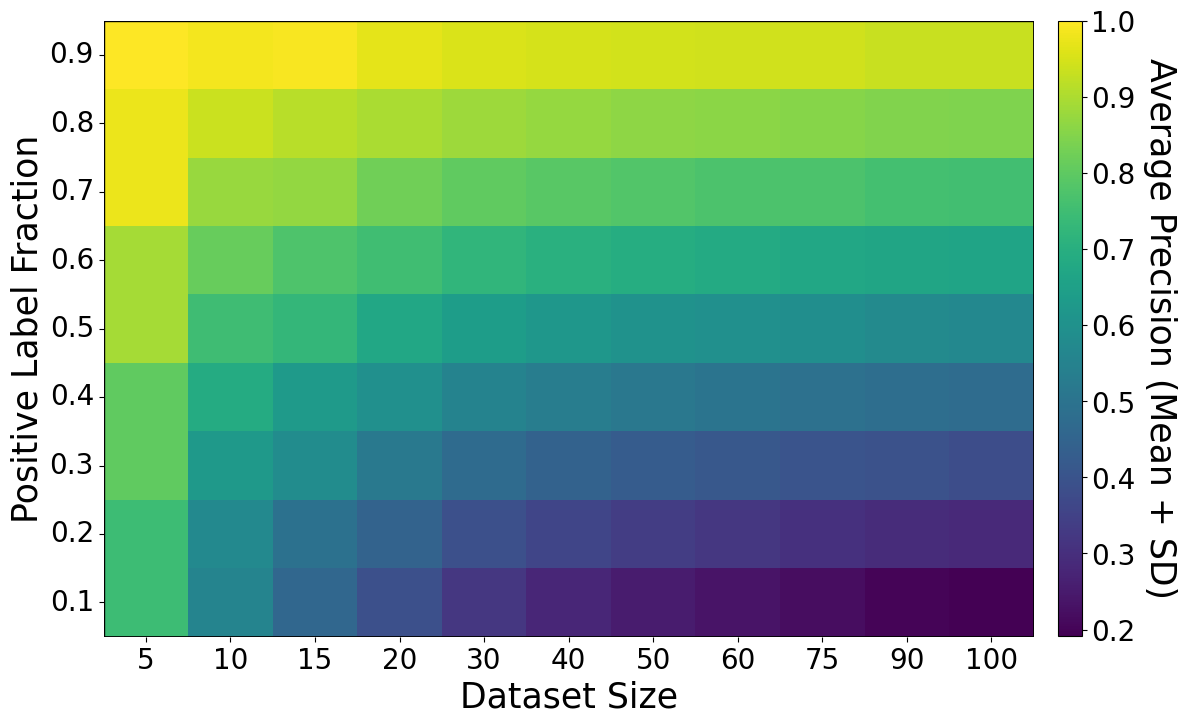

In [13]:
# Plotting the heatmap using sns
fig, ax = plt.subplots(figsize=(12, 8))
hm = sns.heatmap(heatmap, cmap="viridis", cbar=False, ax=ax)

#set ticks in the middle of each cell
ax.set_yticks(np.arange(len(imbalances)) + 0.5)
ax.set_xticks(np.arange(len(dataset_sizes)) + 0.5)
ax.set_yticklabels(pos_fraction,rotation=0)
ax.set_xticklabels(dataset_sizes)

ax.tick_params(axis='both', which='major', labelsize=20)
ax.axhline(y=0, color='k', linewidth=1)
ax.axhline(y=len(imbalances), color='k', linewidth=2)
ax.axvline(x=0, color='k', linewidth=1)
ax.axvline(x=len(dataset_sizes), color='k', linewidth=2)

cbar_ax = fig.add_axes([0.92, 0.111, 0.02, 0.769])
cbar = fig.colorbar(hm.get_children()[0], cax=cbar_ax)
cbar.set_label('Average Precision (Mean + SD)', fontsize=25, rotation=270, labelpad=30)
cbar_ax.tick_params(labelsize=20)
ax.set_ylabel("Positive Label Fraction", size=25)
ax.set_xlabel("Dataset Size", size=25)
plt.show()

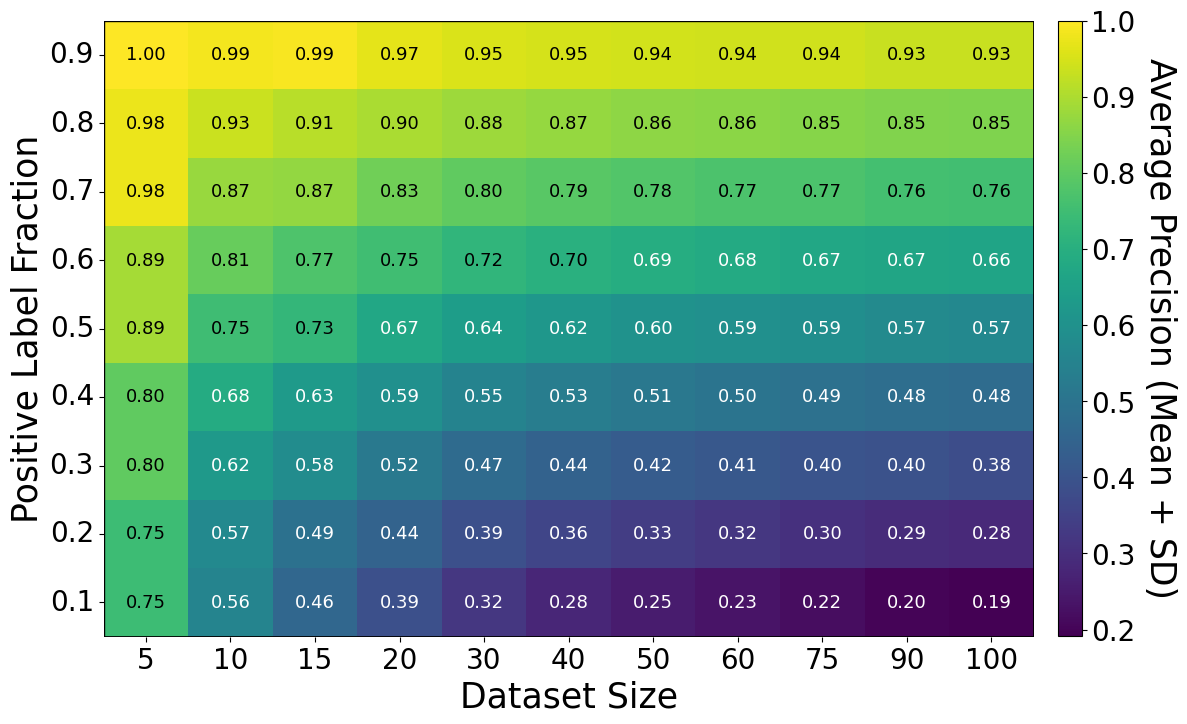

In [14]:
# Plotting the heatmap using sns
fig, ax = plt.subplots(figsize=(12, 8))
cmap = plt.get_cmap("viridis")
hm = sns.heatmap(heatmap, cmap=cmap, cbar=False, ax=ax)

# Annotate each cell with its AP value, using a text color that
# stays readable against that cell's heatmap color
norm = plt.Normalize(vmin=np.nanmin(heatmap), vmax=np.nanmax(heatmap))
for i in range(heatmap.shape[0]):
    for j in range(heatmap.shape[1]):
        value = heatmap[i, j]
        r, g, b, _ = cmap(norm(value))
        # Relative luminance (ITU-R BT.601) to decide readable text color
        luminance = 0.299 * r + 0.587 * g + 0.114 * b
        text_color = "black" if luminance > 0.5 else "white"
        ax.text(j + 0.5, i + 0.5, f"{value:.2f}",
                ha="center", va="center", color=text_color, fontsize=13)

#set ticks in the middle of each cell
ax.set_yticks(np.arange(len(imbalances)) + 0.5)
ax.set_xticks(np.arange(len(dataset_sizes)) + 0.5)
ax.set_yticklabels(pos_fraction,rotation=0)
ax.set_xticklabels(dataset_sizes)

ax.tick_params(axis='both', which='major', labelsize=20)
ax.axhline(y=0, color='k', linewidth=1)
ax.axhline(y=len(imbalances), color='k', linewidth=2)
ax.axvline(x=0, color='k', linewidth=1)
ax.axvline(x=len(dataset_sizes), color='k', linewidth=2)

cbar_ax = fig.add_axes([0.92, 0.111, 0.02, 0.769])
cbar = fig.colorbar(hm.get_children()[0], cax=cbar_ax)
cbar.set_label('Average Precision (Mean + SD)', fontsize=25, rotation=270, labelpad=30)
cbar_ax.tick_params(labelsize=20)
ax.set_ylabel("Positive Label Fraction", size=25)
ax.set_xlabel("Dataset Size", size=25)
plt.show()